# Факторный анализ и метод главных компонент

In [1]:
#pip install factor_analyzer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from factor_analyzer import FactorAnalyzer, Rotator, calculate_bartlett_sphericity, calculate_kmo
import warnings
warnings.filterwarnings("ignore")

# Пример 1

В файле germany.xlsx представлены результаты опроса граждан Германии об их отношении к приезжим рабочим.

Описание переменных:

- id: Идентификатор опрошенного		  
- ewv: Удовлетворённость собственным местом в экономических отношениях (да, нет, нет ответа(9))
- sozeng: Социально-политическая активность (да, нет, нет ответа(9))
- stellung: Занимаемая должность (рабочий, специалист, служащий, нет ответа(9))
- geschl: Пол (мужской, женский)

Следующие 15 переменных оцениваются по шкале Лайкера от 1 до 7, где 1 - полное несогласие, 7 - полное согласие:

- a1	- Необходимо улучшить интеграцию иностранцев
- a2	- Необходимо мягче относится к беженцам
- a3	- Деньги Германии должны быть потрачены на нужды страны
- a4	- Германия - это не служба социальной помощи для всего мира
- a5	- Необходимо стараться налаживать хорошие отношения друг с другом
- a6	- Права беженцев следует ограничить
- a7	- Немцы станут меньшинством
- a8	- Право беженцев необходимо охранять во всей Европе
- a9	- Враждебность к иностранцам наносит вред экономике Германии
- a10	- Сначала необходимо создать нормальные жилищные условия для немцев
- a11	- Мы ведь тоже практически везде являемся иностранцами
- a12	- Мультикультура означает мультикриминал
- a13	- В лодке нет свободных мест
- a14	- Иностранцы вон
- a15	- Интеграция иностранцев - это убийство нации

In [2]:
df1 = pd.read_excel('germany.xlsx', index_col=0)
df1

,ewv,sozeng,stellung,geschl,a1,a2,a3,a4,a5,a6,a7,a8,a9,a10,a11,a12,a13,a14,a15
id,,,,,,,,,,,,,,,,,,,
1,9,нет,служащий,мужской,6,5,4,2,6,5,2,5,6,2,7,4,3,2,1
2,да,9,служащий,женский,6,6,4,3,7,7,2,7,7,4,7,4,1,1,1
3,9,нет,служащий,женский,5,7,7,6,6,6,6,5,5,7,5,4,7,4,1
4,да,9,служащий,мужской,7,6,3,2,7,7,2,5,2,1,2,1,1,1,1
5,да,нет,служащий,мужской,7,5,5,2,7,2,2,6,7,1,7,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,9,да,служащий,мужской,6,6,5,3,6,5,2,6,4,3,4,3,3,1,1
87,да,нет,служащий,женский,7,7,4,1,7,6,1,7,7,5,7,1,2,1,1
88,9,нет,служащий,мужской,6,5,5,5,6,5,4,6,6,5,7,2,4,2,4


## Корреляционная матрица

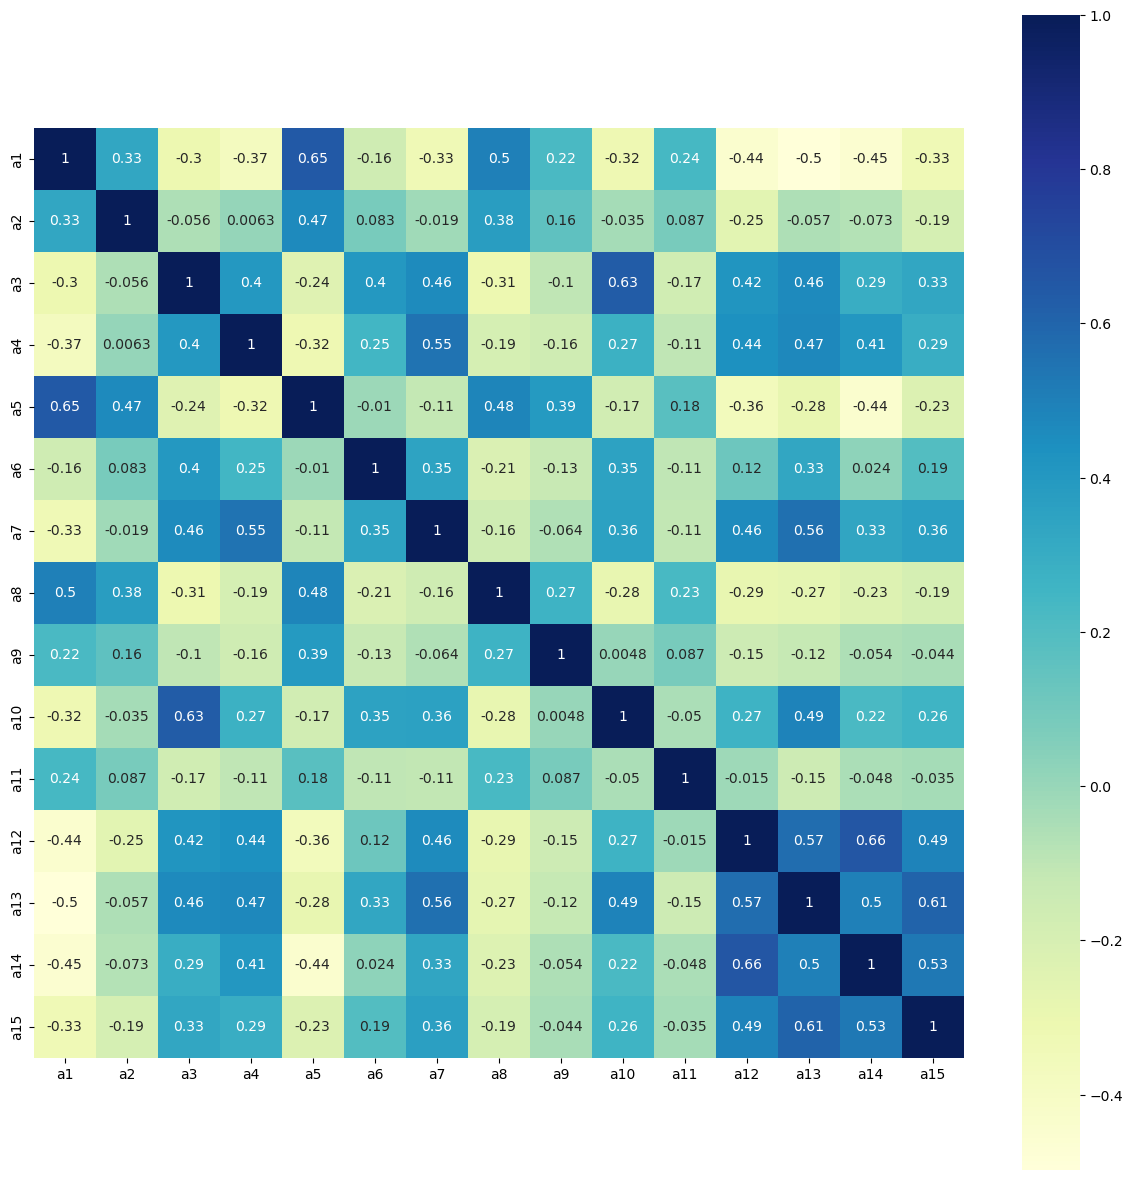

In [4]:
cor = df1.corr(numeric_only=True)
plt.figure(figsize=(15, 15))
sns.heatmap(cor, square = True, cmap='YlGnBu', annot=True)
plt.show()

In [5]:
df1_model = df1[['a1', 'a2', 'a3', 'a4', 'a5', 'a6', 'a7', 'a8', 'a9', 'a10', 'a11', 'a12', 'a13', 'a14', 'a15']]
# формируем датасет, содержащий только переменные, по которым будет проведён анализ

## Оценка применимости факторного анализа данных

In [6]:
calculate_bartlett_sphericity(df1_model)  # результаты теста сферичности Бартлетта

(513.6780436080758, 4.007143691740696e-55)

H0: корреляция между переменными отсутствует (корреляционная матрица является единичной матрицей)

Поскольку p-value < 0.05, H0 отклоняется, между переменными достаточное число статистически значимых корреляций, чтобы провести факторный анализ.

In [7]:
_, kmo_model = calculate_kmo(df1_model)
kmo_model  # KMO

0.8004949016333138

KMO=0.8, коэффициент имеет достаточно высокое значение, данные приемлемы для проведения факторного анализа

## Построение модели для определения числа главных компонент

In [8]:
model1 = FactorAnalyzer(n_factors=15, rotation='varimax', method='principal') 
# строим модель для 15 компонент, что соответствует общему числу переменных
model1.fit(df1_model)

FactorAnalyzer(method='principal', n_factors=15, rotation='varimax',
               rotation_kwargs={})

## Собственные значения и определение числа компонент

In [9]:
ev, v = model1.get_eigenvalues()
ev  # 15 собственных значений

array([5.14623928, 1.94544498, 1.41494146, 0.99011736, 0.93570522,
       0.76014747, 0.69335223, 0.61249812, 0.52938137, 0.47270815,
       0.43334977, 0.3393038 , 0.301026  , 0.24526248, 0.18052231])

In [10]:
5.14623928 + 1.94544498 + 1.41494146 + 0.99011736 + 0.93570522 + 0.76014747 + 0.69335223 + 0.61249812 + 0.52938137 + 0.47270815 + 0.43334977 + 0.3393038 + 0.301026 + 0.24526248 + 0.18052231

14.999999999999996

In [11]:
ev[ev > 1]  # 3 собственных значения выше 1, значит оставляем 3 компонента

array([5.14623928, 1.94544498, 1.41494146])

In [12]:
df1_model.shape

(90, 15)

## Scree Plot

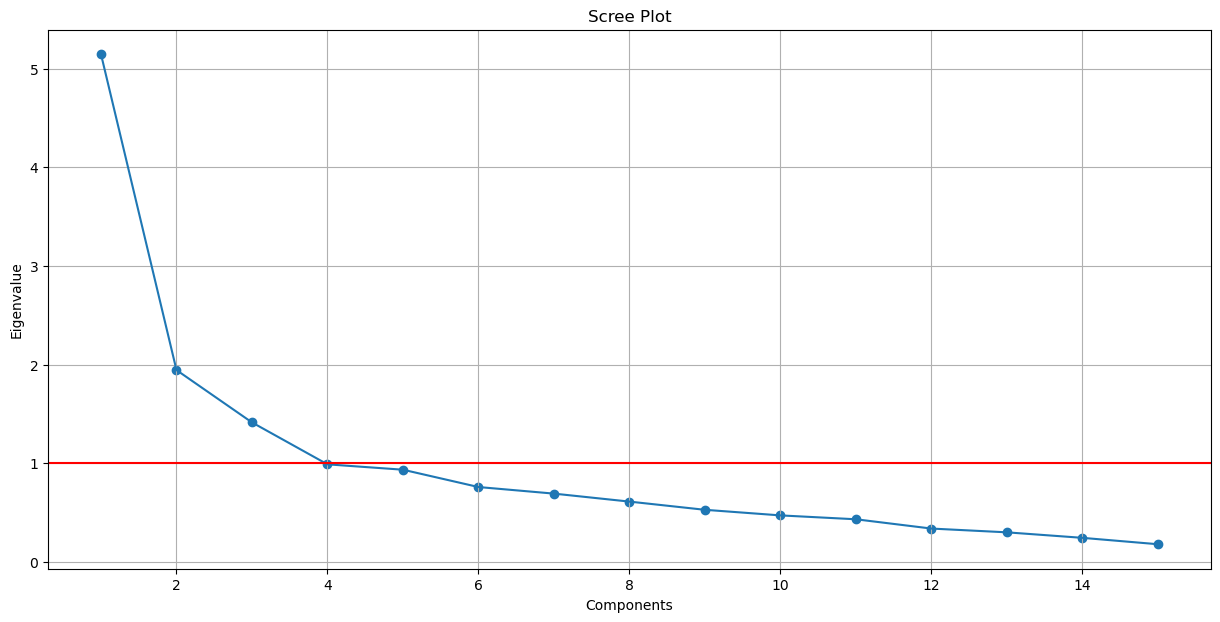

In [13]:
plt.figure(figsize=(15, 7))
plt.scatter(range(1, df1_model.shape[1]+1), ev)
plt.plot(range(1, df1_model.shape[1]+1), ev)
plt.axhline(y=1, color='r', linestyle='-')
plt.title('Scree Plot')
plt.xlabel('Components')
plt.ylabel('Eigenvalue')
plt.grid()
plt.show()

## Построение окончательной модели 

In [14]:
model1 = FactorAnalyzer(n_factors=3, rotation='varimax', method='principal') 
# строим модель для 3 компонент
model1.fit(df1_model)

FactorAnalyzer(method='principal', rotation='varimax', rotation_kwargs={})

## Матрица нагрузок

In [15]:
model1.loadings_

array([[-0.46603975,  0.62839388, -0.1905866 ],
       [-0.1407406 ,  0.65734315,  0.21500615],
       [ 0.32693295, -0.15247981,  0.71039752],
       [ 0.53360461, -0.10608248,  0.39339924],
       [-0.36185645,  0.78329619,  0.04517097],
       [-0.01173528, -0.03762977,  0.76310971],
       [ 0.52501094,  0.03584634,  0.54238501],
       [-0.11658203,  0.71944254, -0.26681602],
       [ 0.02565655,  0.55067052, -0.08863275],
       [ 0.252602  , -0.09501621,  0.68519638],
       [ 0.12459922,  0.39203527, -0.29191954],
       [ 0.80157869, -0.19893723,  0.10740725],
       [ 0.68533398, -0.10991915,  0.46507245],
       [ 0.83682772, -0.14402196, -0.02546221],
       [ 0.72505828, -0.04825814,  0.14392791]])

In [16]:
model_loadings1 = pd.DataFrame(data=model1.loadings_, 
                       index=df1_model.columns, 
                       columns=['Component_1', 'Component_2', 'Component_3'])
model_loadings1

,Component_1,Component_2,Component_3
a1,-0.466040,0.628394,-0.190587
a2,-0.140741,0.657343,0.215006
a3,0.326933,-0.152480,0.710398
a4,0.533605,-0.106082,0.393399
a5,-0.361856,0.783296,0.045171
a6,-0.011735,-0.037630,0.763110
a7,0.525011,0.035846,0.542385
a8,-0.116582,0.719443,-0.266816
a9,0.025657,0.550671,-0.088633
a10,0.252602,-0.095016,0.685196


In [17]:
model_loadings1.index = ['Необходимо улучшить интеграцию иностранцев',
'Необходимо мягче относится к беженцам',
'Деньги Германии должны быть потрачены на нужды страны',
'Германия - это не служба социальной помощи для всего мира',
'Необходимо стараться налаживать хорошие отношения друг с другом',
'Права беженцев следует ограничить',
'Немцы станут меньшинством',
'Право беженцев необходимо охранять во всей Европе',
'Враждебность к иностранцам наносит вред экономике Германии',
'Сначала необходимо создать нормальные жилищные условия для немцев',
'Мы ведь тоже практически везде являемся иностранцами',
'Мультикультура означает мультикриминал',
'В лодке нет свободных мест',
'Иностранцы вон',
'Интеграция иностранцев - это убийство нации']

In [18]:
model_loadings1

,Component_1,Component_2,Component_3
Необходимо улучшить интеграцию иностранцев,-0.466040,0.628394,-0.190587
Необходимо мягче относится к беженцам,-0.140741,0.657343,0.215006
Деньги Германии должны быть потрачены на нужды страны,0.326933,-0.152480,0.710398
Германия - это не служба социальной помощи для всего мира,0.533605,-0.106082,0.393399
Необходимо стараться налаживать хорошие отношения друг с другом,-0.361856,0.783296,0.045171
Права беженцев следует ограничить,-0.011735,-0.037630,0.763110
Немцы станут меньшинством,0.525011,0.035846,0.542385
Право беженцев необходимо охранять во всей Европе,-0.116582,0.719443,-0.266816
Враждебность к иностранцам наносит вред экономике Германии,0.025657,0.550671,-0.088633
Сначала необходимо создать нормальные жилищные условия для немцев,0.252602,-0.095016,0.685196


In [19]:
model_loadings1.sort_values('Component_1', ascending=False)  # отсортируем матрицу по первому столбцу

,Component_1,Component_2,Component_3
Иностранцы вон,0.836828,-0.144022,-0.025462
Мультикультура означает мультикриминал,0.801579,-0.198937,0.107407
Интеграция иностранцев - это убийство нации,0.725058,-0.048258,0.143928
В лодке нет свободных мест,0.685334,-0.109919,0.465072
Германия - это не служба социальной помощи для всего мира,0.533605,-0.106082,0.393399
Немцы станут меньшинством,0.525011,0.035846,0.542385
Деньги Германии должны быть потрачены на нужды страны,0.326933,-0.152480,0.710398
Сначала необходимо создать нормальные жилищные условия для немцев,0.252602,-0.095016,0.685196
Мы ведь тоже практически везде являемся иностранцами,0.124599,0.392035,-0.291920
Враждебность к иностранцам наносит вред экономике Германии,0.025657,0.550671,-0.088633


In [20]:
model_loadings1.sort_values('Component_2', ascending=False)  # отсортируем матрицу по второму столбцу

,Component_1,Component_2,Component_3
Необходимо стараться налаживать хорошие отношения друг с другом,-0.361856,0.783296,0.045171
Право беженцев необходимо охранять во всей Европе,-0.116582,0.719443,-0.266816
Необходимо мягче относится к беженцам,-0.140741,0.657343,0.215006
Необходимо улучшить интеграцию иностранцев,-0.466040,0.628394,-0.190587
Враждебность к иностранцам наносит вред экономике Германии,0.025657,0.550671,-0.088633
Мы ведь тоже практически везде являемся иностранцами,0.124599,0.392035,-0.291920
Немцы станут меньшинством,0.525011,0.035846,0.542385
Права беженцев следует ограничить,-0.011735,-0.037630,0.763110
Интеграция иностранцев - это убийство нации,0.725058,-0.048258,0.143928
Сначала необходимо создать нормальные жилищные условия для немцев,0.252602,-0.095016,0.685196


In [21]:
model_loadings1.sort_values('Component_3', ascending=False)  # отсортируем матрицу по третьем столбцу

,Component_1,Component_2,Component_3
Права беженцев следует ограничить,-0.011735,-0.037630,0.763110
Деньги Германии должны быть потрачены на нужды страны,0.326933,-0.152480,0.710398
Сначала необходимо создать нормальные жилищные условия для немцев,0.252602,-0.095016,0.685196
Немцы станут меньшинством,0.525011,0.035846,0.542385
В лодке нет свободных мест,0.685334,-0.109919,0.465072
Германия - это не служба социальной помощи для всего мира,0.533605,-0.106082,0.393399
Необходимо мягче относится к беженцам,-0.140741,0.657343,0.215006
Интеграция иностранцев - это убийство нации,0.725058,-0.048258,0.143928
Мультикультура означает мультикриминал,0.801579,-0.198937,0.107407
Необходимо стараться налаживать хорошие отношения друг с другом,-0.361856,0.783296,0.045171


In [22]:
#добавить описание компонентов

## Общности

Общность (communality) - это часть дисперсии переменной, обусловленная действием общих факторов. Характерность (specificity) - часть ее дисперсии, обусловленная спецификой данной переменной и ошибками измерения. В сумме общность и характерность для каждой переменной равны 1.

In [23]:
model1.get_communalities()

array([0.64839516, 0.49813558, 0.63479989, 0.45075033, 0.74653343,
       0.58389014, 0.57110295, 0.60237973, 0.31175204, 0.54232993,
       0.25443363, 0.69364074, 0.69805727, 0.72167128, 0.54875361])

In [24]:
communalities1 = pd.DataFrame(data=model1.get_communalities(), 
                       index=df1_model.columns, 
                       columns=['Communalities'])
communalities1.sort_values('Communalities') 

,Communalities
a11,0.254434
a9,0.311752
a4,0.450750
a2,0.498136
a10,0.542330
a15,0.548754
a7,0.571103
a6,0.583890
a8,0.602380
a3,0.634800


In [25]:
communalities1[communalities1.Communalities < 0.3]

,Communalities
a11,0.254434


У переменной a11 "Мы ведь тоже практически везде являемся иностранцами" низкое значение общности, эта переменная не очень хорошо вписалась в модель.

## Процент дисперсии исходных переменных, объясняемой моделью

In [26]:
cumulative_variances = model1.get_factor_variance()[2]
cumulative_variances

array([0.23114119, 0.40020926, 0.56710838])

In [27]:
factor_variance = pd.DataFrame(data=model1.get_factor_variance()[1:3],
                              index=['Proportional variance', 'Cumulative variance'],
                              columns=model_loadings1.columns)
factor_variance

,Component_1,Component_2,Component_3
Proportional variance,0.231141,0.169068,0.166899
Cumulative variance,0.231141,0.400209,0.567108


Модель из 3 компонент объясняет 56,7% вариации значений исходных 15 переменных. При этом 1-ый компонент объясняет 23,1%, второй - 16,9%, а третий - 16,7% вариации значений исходных 15 переменных.

## Сохранение значений компонентов

In [28]:
transformed = pd.DataFrame(data=model1.transform(df1_model),
                           index=df1_model.index,
                           columns=model_loadings1.columns)
transformed.head(20)

,Component_1,Component_2,Component_3
id,,,
1,-0.059275,-0.199022,-1.256665
2,-0.488123,0.733321,-0.323997
3,0.778304,0.161808,1.221614
4,-2.015958,-0.969884,-0.068292
5,-0.624909,0.402465,-1.672938
6,-0.437652,1.241311,-0.116180
7,-0.810154,0.880477,-0.184367
8,-0.758618,0.671378,-1.277712
9,1.331623,1.691812,0.183678


In [29]:
df1 = pd.concat([df1, transformed], axis=1)
df1

,ewv,sozeng,stellung,geschl,a1,a2,a3,a4,a5,a6,...,a9,a10,a11,a12,a13,a14,a15,Component_1,Component_2,Component_3
id,,,,,,,,,,,,,,,,,,,,,
1,9,нет,служащий,мужской,6,5,4,2,6,5,...,6,2,7,4,3,2,1,-0.059275,-0.199022,-1.256665
2,да,9,служащий,женский,6,6,4,3,7,7,...,7,4,7,4,1,1,1,-0.488123,0.733321,-0.323997
3,9,нет,служащий,женский,5,7,7,6,6,6,...,5,7,5,4,7,4,1,0.778304,0.161808,1.221614
4,да,9,служащий,мужской,7,6,3,2,7,7,...,2,1,2,1,1,1,1,-2.015958,-0.969884,-0.068292
5,да,нет,служащий,мужской,7,5,5,2,7,2,...,7,1,7,1,1,1,1,-0.624909,0.402465,-1.672938
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,9,да,служащий,мужской,6,6,5,3,6,5,...,4,3,4,3,3,1,1,-0.847087,-0.507883,-0.251991
87,да,нет,служащий,женский,7,7,4,1,7,6,...,7,5,7,1,2,1,1,-1.060538,0.975653,-0.225020
88,9,нет,служащий,мужской,6,5,5,5,6,5,...,6,5,7,2,4,2,4,0.416453,0.343000,-0.264769


# Пример 2

Файл SAQ.xlsx содержит результаты опроса студентов в одном из американских университетов. В нем следующие переменные:

- q01: Статистика заставляет меня плакать
- q02: Мои друзья подумают, что я глупый(ая), если не смогу справиться с Python
- q03: Стандартные отклонения приводят меня в восторг
- q04. Мне снится, что Пирсон нападает на меня с коэффициентами корреляции
- q05: Я не понимаю статистику
- q06: У меня мало опыта работы с компьютерами
- q07: Все компьютеры меня ненавидят
- q08: Я никогда не был(а) хорош(а) в математике
- q09: Мои друзья лучше меня разбираются в статистике
- q010: Компьютеры полезны только для игр
- q011: В школе у меня были плохие оценки по математике
- q012: Люди пытаются убедить, что Python делает статистику более понятной, но это не так
- q013: Я боюсь, что из-за своей некомпетентности в работе с компьютерами нанесу непоправимый ущерб
- q014: У компьютеров есть собственный разум, и они специально ломаются, когда я ими пользуюсь
- q015: Компьютеры настроены против меня
- q016: Я открыто плачу при упоминании центральной тенденции
- q017: Я впадаю в кому каждый раз, когда вижу уравнение
- q018: Python всегда выдает ошибку, когда я пытаюсь что-то проанализировать с его помощью
- q019: Все смотрят на меня, когда я пишу код на Python
- q020: Я не могу спать из-за мыслей о собственных векторах
- q021: Я просыпаюсь под одеялом с мыслью, что застрял(а) внутри нормального распределения
- q022: Мои друзья лучше меня разбираются в Python
- q023: Если я буду хорош(а) в статистике, друзья подумают, что я зануда

Значения переменных оцениваются по шкале Лайкера:

- 1 — Полностью согласен(а)
- 2 — Скорее согласен(а)
- 3 — Затрудняюсь ответить
- 4 — Скорее не согласен(а)
- 5 — Полностью не согласен(а)

**Задание**: с помощью PCA снизьте размерность данных, дайте названия полученным компонентам и объясните выбор названий. 

In [1]:
['Статистика заставляет меня плакать',
 'Мои друзья подумают, что я глупый(ая), если не смогу справиться с Python',
 'Стандартные отклонения приводят меня в восторг',
 'Мне снится, что Пирсон нападает на меня с коэффициентами корреляции',
 'Я не понимаю статистику',
 'У меня мало опыта работы с компьютерами',
 'Все компьютеры меня ненавидят',
 'Я никогда не был(а) хорош(а) в математике',
 'Мои друзья лучше меня разбираются в статистике',
 'Компьютеры полезны только для игр',
 'В школе у меня были плохие оценки по математике',
 'Люди пытаются убедить, что Python делает статистику более понятной, но это не так',
 'Я боюсь, что из-за своей некомпетентности в работе с компьютерами нанесу непоправимый ущерб',
 'У компьютеров есть собственный разум, и они специально ломаются, когда я ими пользуюсь',
 'Компьютеры настроены против меня',
 'Я открыто плачу при упоминании центральной тенденции',
 'Я впадаю в кому каждый раз, когда вижу уравнение',
 'Python всегда выдает ошибку, когда я пытаюсь что-то проанализировать с его помощью',
 'Все смотрят на меня, когда я пишу код на Python',
 'Я не могу спать из-за мыслей о собственных векторах',
 'Я просыпаюсь под одеялом с мыслью, что застрял(а) внутри нормального распределения',
 'Мои друзья лучше меня разбираются в Python',
 'Если я буду хорош(а) в статистике, друзья подумают, что я зануда']

In [ ]:
# здесь написать решение